# World Cup 2026 Forecast Story

This notebook presents the portfolio-facing narrative of the **World Cup 2026 forecasting system**.

It is designed to communicate the project in a concise and compelling way:

- what problem is being solved
- how the forecast is built
- who the main title contenders are
- where uncertainty remains
- why simulation is a better framing than deterministic brackets

This notebook is **not part of the production pipeline**.  
Its role is to communicate model and simulation insights clearly for portfolio, interview, and stakeholder presentation purposes.


## Storytelling roadmap

This notebook follows six steps:

1. Frame the tournament forecasting problem
2. Summarize the modeling and simulation methodology
3. Present the main championship forecast
4. Compare progression probabilities across contenders
5. Quantify uncertainty and forecast concentration
6. Conclude with key takeaways and limitations


### Project paths setup

Resolve project root and load simulation artifacts generated by the tournament simulation engine.

In [1]:


from pathlib import Path

# Detect project root
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Simulation outputs directory
SIM_OUTPUT = PROJECT_ROOT / "data" / "outputs" / "simulation"

team_probs = SIM_OUTPUT / "team_probabilities.csv"
champion_dist = SIM_OUTPUT / "champion_distribution.csv"
summary_metadata_path = SIM_OUTPUT / "summary_metadata.json"
match_logs_path = SIM_OUTPUT / "match_logs.parquet"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

team_probabilities = pd.read_csv(team_probs)
champion_distribution = pd.read_csv(champion_dist)

summary_metadata = None
if summary_metadata_path.exists():
    with open(summary_metadata_path) as f:
        summary_metadata = json.load(f)

match_logs_df = None
if match_logs_path.exists():
    match_logs_df = pd.read_parquet(match_logs_path)

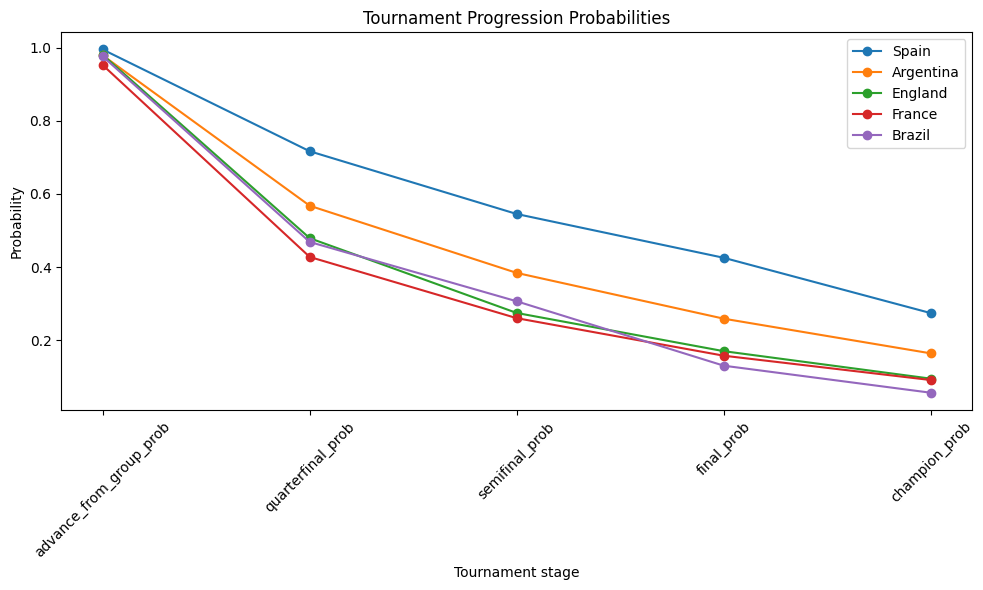

In [3]:
stage_cols = [
    c for c in [
        "advance_from_group_prob",
        "quarterfinal_prob",
        "semifinal_prob",
        "final_prob",
        "champion_prob",
    ]
    if c in team_probabilities.columns
]

top_5_progression = (
    team_probabilities
    .sort_values("champion_prob", ascending=False)
    .head(5)
    .set_index("team")[stage_cols]
)

plt.figure(figsize=(10, 6))

for team in top_5_progression.index:
    plt.plot(
        top_5_progression.columns,
        top_5_progression.loc[team],
        marker="o",
        label=team,
    )

plt.title("Tournament Progression Probabilities")
plt.xlabel("Tournament stage")
plt.ylabel("Probability")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

output_dir = PROJECT_ROOT / "docs" / "images"
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / "team_progression.png", dpi=300)

plt.show()

## 1. Forecasting objective

The objective of the project is to estimate **tournament-level probabilities** for the FIFA World Cup 2026.

Rather than producing a single bracket prediction, the system estimates:

- the probability that each team advances from the group stage
- the probability of reaching each knockout round
- the probability of winning the tournament

This is a better representation of football forecasting because knockout tournaments are inherently stochastic.


## 2. Methodology at a glance

The forecasting workflow combines two layers:

### Match prediction layer
A probabilistic match model estimates:

- `P(win)`
- `P(draw)`
- `P(loss)`

from the perspective of Team A using historical match data and engineered team-strength features.

### Tournament simulation layer
Those match probabilities are used inside a **Monte Carlo tournament simulator**:

```text
predict_match(team_a, team_b)
↓
sample match outcome
↓
update tournament state
↓
simulate full tournament
↓
repeat thousands of times
```

The result is a probability distribution over tournament outcomes rather than a single deterministic bracket.


## 3. Load forecast artifacts

The notebook reads the simulation outputs generated by the reporting layer.

Expected files:

- `team_probabilities.csv`
- `champion_distribution.csv`
- `summary_metadata.json` (optional)
- `match_logs.parquet` (optional)


In [4]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
SIM_OUTPUT_PATH = PROJECT_ROOT / "data" / "outputs" / "simulation"

team_prob_path = SIM_OUTPUT_PATH / "team_probabilities.csv"
champion_dist_path = SIM_OUTPUT_PATH / "champion_distribution.csv"
summary_metadata_path = SIM_OUTPUT_PATH / "summary_metadata.json"
match_logs_path = SIM_OUTPUT_PATH / "match_logs.parquet"

print("Simulation output directory:", SIM_OUTPUT_PATH)
print("team_probabilities exists:", team_prob_path.exists())
print("champion_distribution exists:", champion_dist_path.exists())
print("summary_metadata exists:", summary_metadata_path.exists())
print("match_logs exists:", match_logs_path.exists())

Simulation output directory: C:\Users\manue\Projects\world-cup-2026-forecast\data\outputs\simulation
team_probabilities exists: True
champion_distribution exists: True
summary_metadata exists: True
match_logs exists: True


In [5]:
import json

team_probabilities = pd.read_csv(team_prob_path)
champion_distribution = pd.read_csv(champion_dist_path)

summary_metadata = None
if summary_metadata_path.exists():
    with open(summary_metadata_path, "r", encoding="utf-8") as f:
        summary_metadata = json.load(f)

match_logs_df = None
if match_logs_path.exists():
    match_logs_df = pd.read_parquet(match_logs_path)

print("team_probabilities shape:", team_probabilities.shape)
print("champion_distribution shape:", champion_distribution.shape)
if summary_metadata is not None:
    print("summary_metadata keys:", list(summary_metadata.keys()))
if match_logs_df is not None:
    print("match_logs shape:", match_logs_df.shape)

team_probabilities shape: (48, 10)
champion_distribution shape: (37, 3)
summary_metadata keys: ['tournament_name', 'tournament_id', 'model_name', 'neutral_venue', 'knockout_draw_resolution', 'num_groups', 'group_size', 'teams_advancing_per_group', 'best_third_qualifiers', 'initial_knockout_round', 'num_simulations', 'num_teams']
match_logs shape: (1030000, 12)


## 4. Simulation configuration

This table provides context on the forecast generation setup.


In [6]:
if summary_metadata is not None:
    pd.DataFrame([summary_metadata])
else:
    print("summary_metadata.json not available.")

## 5. Main championship forecast

We first rank teams by **championship probability**. This is the most direct summary of the forecast.


In [7]:
champion_dist_sorted = champion_distribution.sort_values("champion_prob", ascending=False).reset_index(drop=True)
champion_dist_sorted.head(15)

,team,titles,champion_prob
0,Spain,2743,0.2743
1,Argentina,1643,0.1643
2,England,952,0.0952
3,France,914,0.0914
4,Brazil,567,0.0567
5,Netherlands,471,0.0471
6,Colombia,404,0.0404
7,Portugal,324,0.0324
8,Ecuador,238,0.0238
9,Morocco,228,0.0228


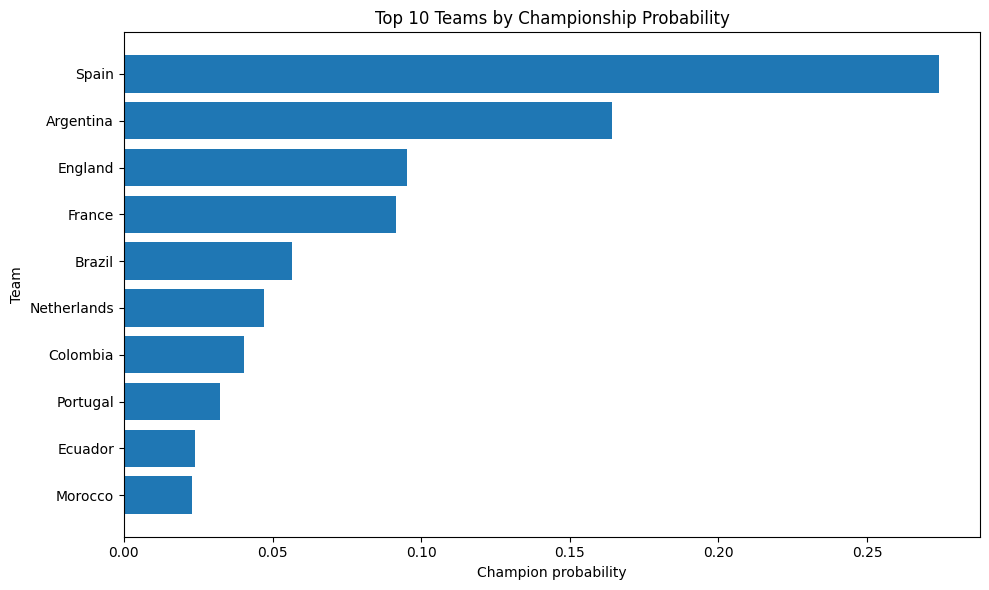

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

top_10_champion = champion_dist_sorted.head(10).copy()

plt.figure(figsize=(10,6))
plt.barh(top_10_champion["team"], top_10_champion["champion_prob"])

plt.xlabel("Champion probability")
plt.ylabel("Team")
plt.title("Top 10 Teams by Championship Probability")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

### Championship contenders

The updated simulation results reveal a **clear leading favorite and a competitive group of challengers**, rather than two equally dominant teams.

**Spain emerges as the strongest title contender**, with a championship probability of approximately **27%**, clearly separating itself from the rest of the field.

**Argentina remains the second most likely champion**, with a probability around **16%**, forming a distinct second position but no longer at the same level as Spain.

A second tier of contenders includes **England, France, Brazil, and the Netherlands**, each with championship probabilities generally ranging between **4% and 10%**. These teams remain highly competitive but require more favorable knockout paths to secure the title.

Additional teams such as **Colombia, Portugal, and Ecuador** retain meaningful chances, benefiting from specific bracket realizations in the simulation.

Overall, the forecast now reflects a structure with **one dominant favorite, a strong secondary contender, and a broader competitive tier**, rather than two co-equal leaders.


## 6. Team progression profile

Championship probability alone can hide important structural differences.

A team may have:

- a strong chance to advance from the group stage
- a decent chance to reach quarterfinals
- but a much lower probability of winning the title

Progression probabilities reveal where teams are most likely to drop out.


In [9]:
team_prob_sorted = team_probabilities.sort_values("champion_prob", ascending=False).reset_index(drop=True)
team_prob_sorted.head(20)

,team,group_stage_exit_prob,round_of_32_prob,round_of_16_prob,quarterfinal_prob,semifinal_prob,final_prob,champion_prob,advance_from_group_prob,non_champion_prob
0,Spain,0.0051,0.9949,0.8647,0.7167,0.5452,0.4255,0.2743,0.9949,0.7257
1,Argentina,0.0212,0.9788,0.8239,0.5678,0.3842,0.2591,0.1643,0.9788,0.8357
2,England,0.0198,0.9802,0.7473,0.4791,0.2747,0.1703,0.0952,0.9802,0.9048
3,France,0.0476,0.9524,0.7651,0.4278,0.2605,0.1579,0.0914,0.9524,0.9086
4,Brazil,0.0239,0.9761,0.6708,0.4688,0.3066,0.1306,0.0567,0.9761,0.9433
5,Netherlands,0.0494,0.9506,0.6641,0.4105,0.1868,0.1052,0.0471,0.9506,0.9529
6,Colombia,0.0121,0.9879,0.5838,0.3132,0.1662,0.0805,0.0404,0.9879,0.9596
7,Portugal,0.0099,0.9901,0.5806,0.3128,0.1516,0.0705,0.0324,0.9901,0.9676
8,Ecuador,0.0768,0.9232,0.5898,0.3171,0.1383,0.0630,0.0238,0.9232,0.9762
9,Morocco,0.0412,0.9588,0.5241,0.2967,0.1493,0.0569,0.0228,0.9588,0.9772


In [10]:
stage_cols = [
    c for c in [
        "advance_from_group_prob",
        "round_of_16_prob",
        "quarterfinal_prob",
        "semifinal_prob",
        "final_prob",
        "champion_prob",
    ]
    if c in team_prob_sorted.columns
]

progression_table = team_prob_sorted[["team"] + stage_cols].head(12).copy()
progression_table

,team,advance_from_group_prob,round_of_16_prob,quarterfinal_prob,semifinal_prob,final_prob,champion_prob
0,Spain,0.9949,0.8647,0.7167,0.5452,0.4255,0.2743
1,Argentina,0.9788,0.8239,0.5678,0.3842,0.2591,0.1643
2,England,0.9802,0.7473,0.4791,0.2747,0.1703,0.0952
3,France,0.9524,0.7651,0.4278,0.2605,0.1579,0.0914
4,Brazil,0.9761,0.6708,0.4688,0.3066,0.1306,0.0567
5,Netherlands,0.9506,0.6641,0.4105,0.1868,0.1052,0.0471
6,Colombia,0.9879,0.5838,0.3132,0.1662,0.0805,0.0404
7,Portugal,0.9901,0.5806,0.3128,0.1516,0.0705,0.0324
8,Ecuador,0.9232,0.5898,0.3171,0.1383,0.0630,0.0238
9,Morocco,0.9588,0.5241,0.2967,0.1493,0.0569,0.0228


In [11]:
top_8_teams = team_prob_sorted["team"].head(8).tolist()

plot_df = (
    team_prob_sorted[team_prob_sorted["team"].isin(top_8_teams)][["team"] + stage_cols]
    .set_index("team")
    .T
)

plot_df

team,Spain,Argentina,England,France,Brazil,Netherlands,Colombia,Portugal
advance_from_group_prob,0.9949,0.9788,0.9802,0.9524,0.9761,0.9506,0.9879,0.9901
round_of_16_prob,0.8647,0.8239,0.7473,0.7651,0.6708,0.6641,0.5838,0.5806
quarterfinal_prob,0.7167,0.5678,0.4791,0.4278,0.4688,0.4105,0.3132,0.3128
semifinal_prob,0.5452,0.3842,0.2747,0.2605,0.3066,0.1868,0.1662,0.1516
final_prob,0.4255,0.2591,0.1703,0.1579,0.1306,0.1052,0.0805,0.0705
champion_prob,0.2743,0.1643,0.0952,0.0914,0.0567,0.0471,0.0404,0.0324


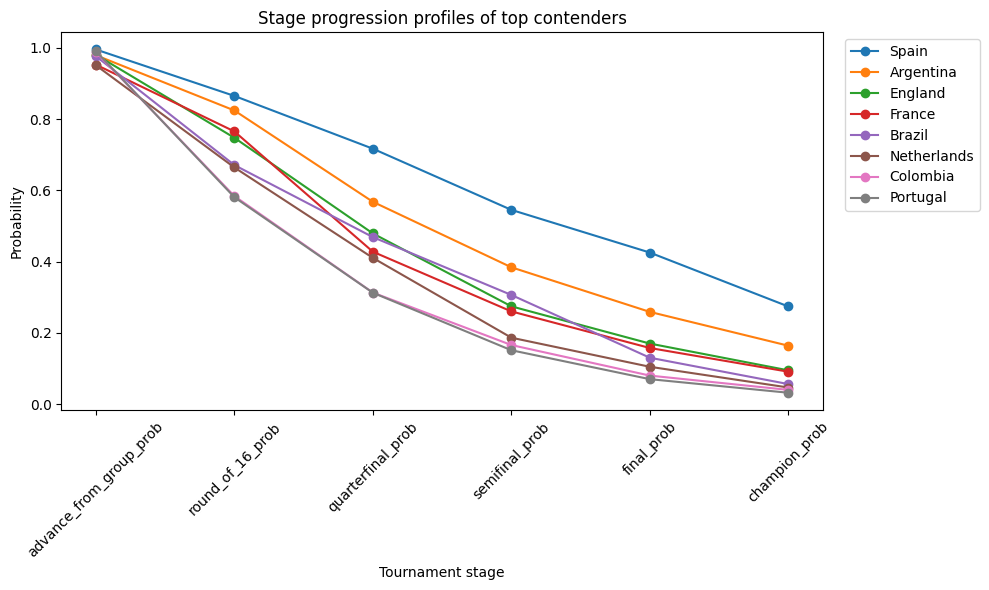

In [12]:
plt.figure(figsize=(10, 6))

for team in plot_df.columns:
    plt.plot(plot_df.index, plot_df[team], marker="o", label=team)

plt.title("Stage progression profiles of top contenders")
plt.xlabel("Tournament stage")
plt.ylabel("Probability")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Progression profiles

Examining progression probabilities across tournament stages provides further insight into the structure of the forecast.

**Spain demonstrates the most consistent dominance across all stages**, maintaining high probabilities of advancing deep into the tournament and converting those runs into championships.

**Argentina also shows strong progression**, though with slightly higher variance in later rounds compared to Spain.

Teams such as **England and France** exhibit solid advancement probabilities through early knockout stages but experience sharper declines in semifinal and final probabilities, suggesting greater sensitivity to opponent strength.

In contrast, several mid-tier teams reach the **Round of 16 and quarterfinals** with reasonable frequency but struggle to maintain momentum against top-tier opponents.

This progression analysis highlights a key distinction between:

- **structural contenders** (consistent across all stages), and  
- **situational contenders** (dependent on favorable matchups).



## 7. Favorites, second tier, and dark horses

A useful portfolio-level framing is to bucket teams into narrative tiers.


In [13]:
forecast_story_df = team_prob_sorted[[
    "team",
    "champion_prob",
    *[c for c in ["semifinal_prob", "final_prob", "advance_from_group_prob"] if c in team_prob_sorted.columns]
]].copy()

forecast_story_df["tier"] = np.select(
    [
        forecast_story_df["champion_prob"] >= 0.15,
        forecast_story_df["champion_prob"] >= 0.05,
        forecast_story_df["champion_prob"] >= 0.01,
    ],
    [
        "Top favorite",
        "Strong contender",
        "Dark horse",
    ],
    default="Long shot",
)

forecast_story_df.head(20)

,team,champion_prob,semifinal_prob,final_prob,advance_from_group_prob,tier
0,Spain,0.2743,0.5452,0.4255,0.9949,Top favorite
1,Argentina,0.1643,0.3842,0.2591,0.9788,Top favorite
2,England,0.0952,0.2747,0.1703,0.9802,Strong contender
3,France,0.0914,0.2605,0.1579,0.9524,Strong contender
4,Brazil,0.0567,0.3066,0.1306,0.9761,Strong contender
5,Netherlands,0.0471,0.1868,0.1052,0.9506,Dark horse
6,Colombia,0.0404,0.1662,0.0805,0.9879,Dark horse
7,Portugal,0.0324,0.1516,0.0705,0.9901,Dark horse
8,Ecuador,0.0238,0.1383,0.0630,0.9232,Dark horse
9,Morocco,0.0228,0.1493,0.0569,0.9588,Dark horse


In [14]:
forecast_story_df["tier"].value_counts().rename_axis("tier").reset_index(name="num_teams")

,tier,num_teams
0,Long shot,31
1,Dark horse,12
2,Strong contender,3
3,Top favorite,2


In [15]:
forecast_story_df["tier"].value_counts()

tier
Long shot           31
Dark horse          12
Strong contender     3
Top favorite         2
Name: count, dtype: int64

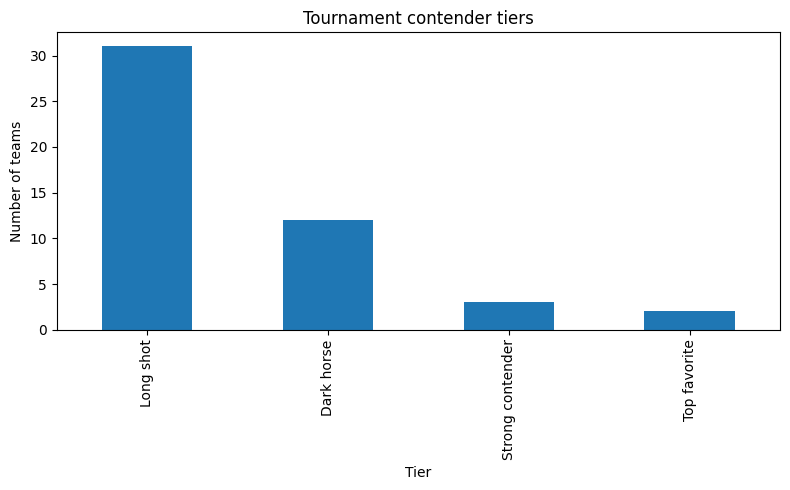

In [16]:
import matplotlib.pyplot as plt

tier_counts = forecast_story_df["tier"].value_counts()

plt.figure(figsize=(8,5))
tier_counts.plot(kind="bar")

plt.title("Tournament contender tiers")
plt.ylabel("Number of teams")
plt.xlabel("Tier")

plt.tight_layout()
plt.show()

### Contender tiers

Based on championship probabilities, teams can be grouped into the following tiers:

- **Dominant favorite (1 team)**  
  Spain

- **Primary contender (1 team)**  
  Argentina

- **Strong contenders (4–5 teams)**  
  England, France, Brazil, Netherlands (and occasionally Colombia depending on simulation variance)

- **Competitive tier / dark horses (~8–12 teams)**  
  Portugal, Colombia, Ecuador, Senegal, Uruguay, Italy, Croatia, Germany, Switzerland

- **Long tail (remaining teams)**  
  Teams with low but non-zero championship probability, reflecting the stochastic nature of knockout tournaments.

This tier structure reflects a **moderately concentrated forecast**, where a small number of teams dominate title probability but a broader set remains capable of deep tournament runs.


## 8. Forecast concentration and uncertainty

A forecast is not just about ranking teams. It is also about understanding **how concentrated** the probability mass is.

We compute:

- top-5 championship probability mass
- top-10 championship probability mass
- entropy of the champion distribution


In [17]:
top_5_mass = champion_dist_sorted["champion_prob"].head(5).sum()
top_10_mass = champion_dist_sorted["champion_prob"].head(10).sum()

entropy = -(champion_dist_sorted["champion_prob"] * np.log(
    np.clip(champion_dist_sorted["champion_prob"], 1e-12, 1)
)).sum()

uncertainty_summary = pd.DataFrame([{
    "top_5_champion_probability_mass": top_5_mass,
    "top_10_champion_probability_mass": top_10_mass,
    "champion_distribution_entropy": entropy,
}]).round(4)

uncertainty_summary

,top_5_champion_probability_mass,top_10_champion_probability_mass,champion_distribution_entropy
0,0.6819,0.8484,2.4962


## Forecast concentration

The championship probability distribution reveals a **moderately concentrated forecast**, with a clear leading group of contenders.

The **top five teams account for approximately 68%** of total championship probability mass, while the **top ten teams represent around 85%** of the distribution.

This indicates that although a relatively small group of teams dominates the forecast, the model still assigns meaningful probability to a broader set of contenders.

The **entropy of the champion distribution (~2.50)** reflects this balance, suggesting that the tournament outcome remains meaningfully uncertain despite the presence of a strong favorite.

Overall, the forecast combines **top-heavy structure with long-tail uncertainty**, a typical characteristic of knockout tournament predictions.


## 9. Optional match-log diagnostics

If match-level logs are available, they can be used for QA and realism checks.

Examples:

- stage distribution of simulated matches
- winner frequencies
- upset-rate analysis
- knockout-round behavior

If the required probability columns are not available in the logs, upset analysis may not be possible yet.


In [18]:
if match_logs_df is not None:
    print("Available match log columns:")
    print(sorted(match_logs_df.columns))
else:
    print("match_logs.parquet not available.")

Available match log columns:
['decided_by', 'draw_prob', 'outcome', 'simulation_id', 'stage', 'team_a', 'team_a_goals', 'team_a_loss_prob', 'team_a_win_prob', 'team_b', 'team_b_goals', 'winner']


In [19]:
if match_logs_df is not None and "stage" in match_logs_df.columns:
    match_logs_df["stage"].value_counts().rename_axis("stage").reset_index(name="matches")
else:
    print("Stage-level match diagnostics not available.")

## Interpreting uncertainty in tournament forecasts

Even the strongest teams rarely exceed championship probabilities above **25–30%** in realistic tournament forecasting models.

This reflects the inherent randomness of knockout competitions. A single unfavorable matchup, an early red card, or a penalty shootout can dramatically alter the outcome of the tournament.

Therefore, a team with a **20–30% championship probability** should not be interpreted as a guaranteed winner, but rather as the most likely outcome among many plausible scenarios.

The simulation framework captures this uncertainty by repeatedly sampling match outcomes and tournament paths, producing a distribution of possible tournament results rather than a single deterministic prediction.

This probabilistic perspective is essential for understanding both **model outputs and real-world tournament dynamics**.

## 10. Executive summary

At the highest level, this forecasting system produces three types of insight:

1. **Who the favorites are**  
   Championship probabilities reveal the strongest title contenders.

2. **How far teams are likely to go**  
   Stage-level probabilities distinguish deep contenders from early-round specialists.

3. **How uncertain the tournament remains**  
   Concentration metrics and entropy quantify whether the title race is narrow or open.

This is more informative than a single bracket prediction because it respects the uncertainty inherent in football tournaments.


## 11. Limitations

This forecast should be interpreted with several constraints in mind:

- It is driven by a **match-outcome model** rather than a full goal-scoring model.
- It does not yet incorporate **player availability, injuries, or final squad selection**.
- The tournament configuration may still evolve if final qualified teams or official groups are not yet fixed.
- The bracket implementation uses a **deterministic approximation of third-place assignments**, rather than the full FIFA mapping.
- Forecast quality ultimately depends on the **calibration and realism of the underlying match probabilities**.

These limitations are typical for a baseline probabilistic forecasting system and point directly to the next development steps.


## 12. Conclusions

Using a Monte Carlo simulation framework combined with a probabilistic match prediction model, this analysis estimates the likelihood of each team advancing through the stages of the FIFA World Cup 2026.

The results highlight **Spain as the clear leading title contender**, with a championship probability around **27%**, followed by **Argentina (~16%)** as the second most likely champion.

A broader group of strong teams — including **England, France, Brazil, and the Netherlands** — retains meaningful chances of winning the tournament, while a wider set of teams remains capable of producing deep runs under favorable conditions.

Despite the presence of a dominant favorite, the forecast remains far from deterministic. The top five teams account for roughly two-thirds of the total championship probability mass, leaving substantial room for unexpected outcomes.

This uncertainty is a defining characteristic of international knockout tournaments and underscores the value of probabilistic forecasting approaches. Rather than predicting a single outcome, the simulation framework provides a full distribution of possible tournament scenarios, offering a more realistic representation of competitive uncertainty.

Future work could extend this framework through improved match-level models, richer feature engineering, better probability calibration, and deeper analysis of the interaction between match predictions and tournament structure.


## 13. Next storytelling extensions

Useful additions for future portfolio iterations:

- Annotate the forecast with **team-level tactical or contextual insights**
- Add **bracket path visualizations** for top contenders
- Compare **multiple model versions** (e.g., logistic regression vs boosting models)
- Include **interactive dashboards or visual summaries** of simulation outputs
- Introduce **scenario analysis**, such as injuries, Elo updates, or alternative tournament configurations
